In [71]:
import pandas as pd
import pickle
import json
import matplotlib.pyplot as plt
from matplotlib.ticker import FormatStrFormatter
import numpy as np

# INITIAL EXPERIMENTATION (MOTIVATION) + TERMINATION RESILIENCE (COMBINED)

In [72]:
simple_failure_data = None
with open("final_simple_failure_data", 'r') as file:
    simple_failure_data = json.load(file)

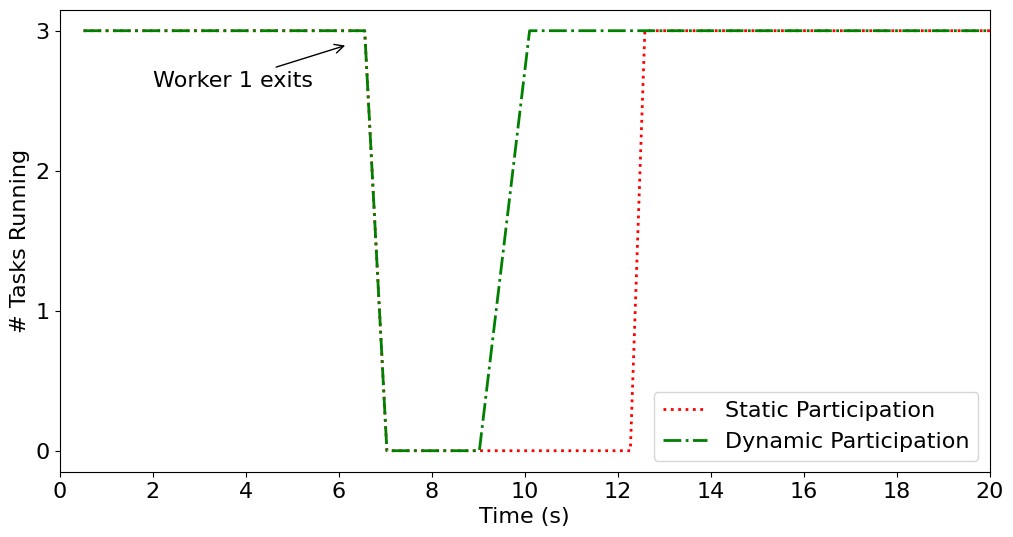

In [73]:
fig,ax = plt.subplots(figsize=(12, 6))
plt.plot([x["time"] for x in simple_failure_data], [x["original_workers"] for x in simple_failure_data], 'r:', label="Static Participation", lw=2)
plt.plot([x["time"] for x in simple_failure_data], [x["new_workers"] for x in simple_failure_data], 'g-.', label="Dynamic Participation", lw=2)
plt.ylabel("# Tasks Running", fontsize=16)
plt.xlabel("Time (s)", fontsize=16)
plt.legend(fontsize=16)
plt.xlim(0, 20)

plt.annotate("Worker 1 exits", (6.2, 2.9), xytext=(2, 2.6), arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=16)

ax.set_yticks(ticks=plt.yticks()[0][1::2], labels=plt.yticks()[0].astype(int)[1::2],  fontsize=16)
ax.set_xticks(ticks=list(range(0, 21, 2)), labels=list(range(0, 21, 2)),  fontsize=16)

In [74]:
long_failure_data = None
with open("final_long_failure_data", 'r') as file:
    long_failure_data = json.load(file)

Text(22, 6.9, 'Worker 1 exits')

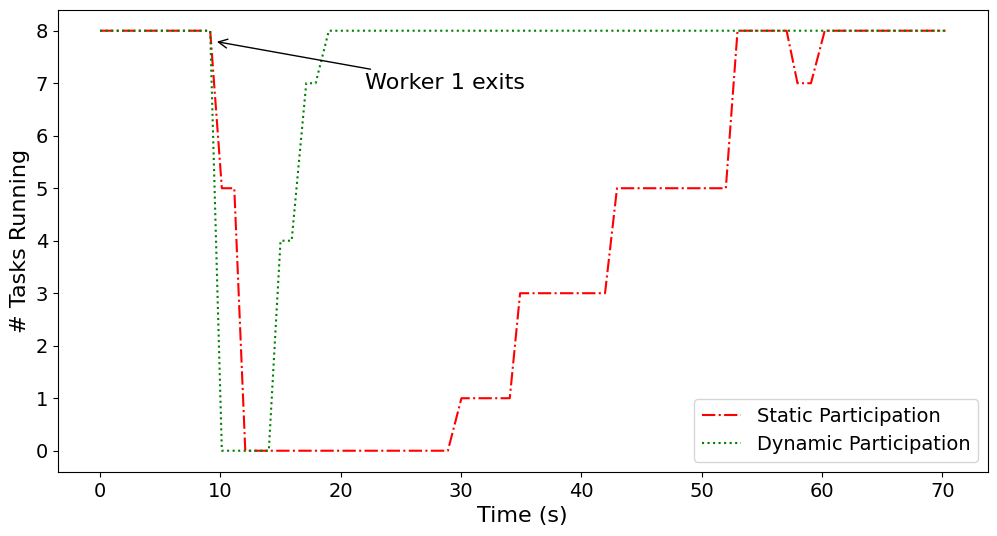

In [75]:
fig,ax = plt.subplots(figsize=(12, 6))
plt.plot([x["time"] for x in long_failure_data], [x["original_workers"] for x in long_failure_data], 'r-.', label="Static Participation")
plt.plot([x["time"] for x in long_failure_data], [x["new_workers"] for x in long_failure_data], 'g:', label="Dynamic Participation")
plt.ylabel("# Tasks Running", fontsize=16)
plt.xlabel("Time (s)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend(fontsize=14)

plt.annotate("Worker 1 exits", (9.5, 7.8), xytext=(8+14, 7.9-1), arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=16)

In [76]:
chaos_data = None
with open("final_chaos_data", 'r') as file:
    chaos_data = json.load(file)

/var/folders/_6/bbdc6b196n7_my7xjh4dj0000000gn/T/ipykernel_29385/2927173337.py:3: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  ax.plot([x["time"] for x in chaos_data], [x["running"] for x in chaos_data], 'g--', label='Running', color='green')
/var/folders/_6/bbdc6b196n7_my7xjh4dj0000000gn/T/ipykernel_29385/2927173337.py:4: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  ax.plot([x["time"] for x in chaos_data], [x["scheduled"] for x in chaos_data], 'g--', label='Node Scheduled', color='orange')
/var/folders/_6/bbdc6b196n7_my7xjh4dj0000000gn/T/ipykernel_29385/2927173337.py:5: UserWarning: color is redundantly defined by the 'color' keyword argument and the fmt string "g--" (-> color='g'). The keyword argument will take precedence.
  ax.plot([x["time"] for x in chao

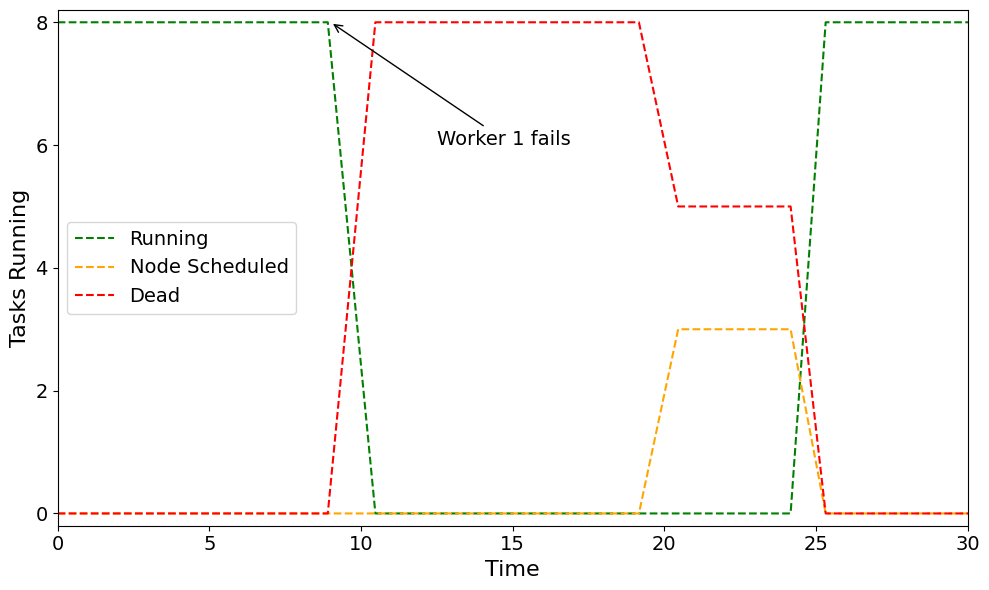

In [77]:
fig, ax = plt.subplots(figsize=(10, 6))

ax.plot([x["time"] for x in chaos_data], [x["running"] for x in chaos_data], 'g--', label='Running', color='green')
ax.plot([x["time"] for x in chaos_data], [x["scheduled"] for x in chaos_data], 'g--', label='Node Scheduled', color='orange')
ax.plot([x["time"] for x in chaos_data], [x["dead"] for x in chaos_data], 'g--', label='Dead', color='red')
ax.set_xlabel('Time', fontsize=16)
ax.set_ylabel('Tasks Running', fontsize=16)
ax.legend(fontsize=14)

ax.set_xlim(0, 30)
ax.set_ylim(-0.2, 8.2)

ax.annotate("Worker 1 fails", (9, 8), xytext=(23.5-11, 6), arrowprops=dict(facecolor='black', arrowstyle='->'), fontsize=14)

plt.yticks(ticks=plt.yticks()[0][1::2], labels=plt.yticks()[0].astype(int)[1::2], fontsize=14)
plt.xticks(fontsize=14)

plt.tight_layout()
plt.show()

# ELASTICITY

In [78]:
elasticity_data = None
with open("final_elasticity_data", 'r') as file:
    elasticity_data = json.load(file)

/var/folders/_6/bbdc6b196n7_my7xjh4dj0000000gn/T/ipykernel_29385/2884283743.py:9: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([x*20 for x in range(0, 15)])


Text(118, 4.2, 'j')

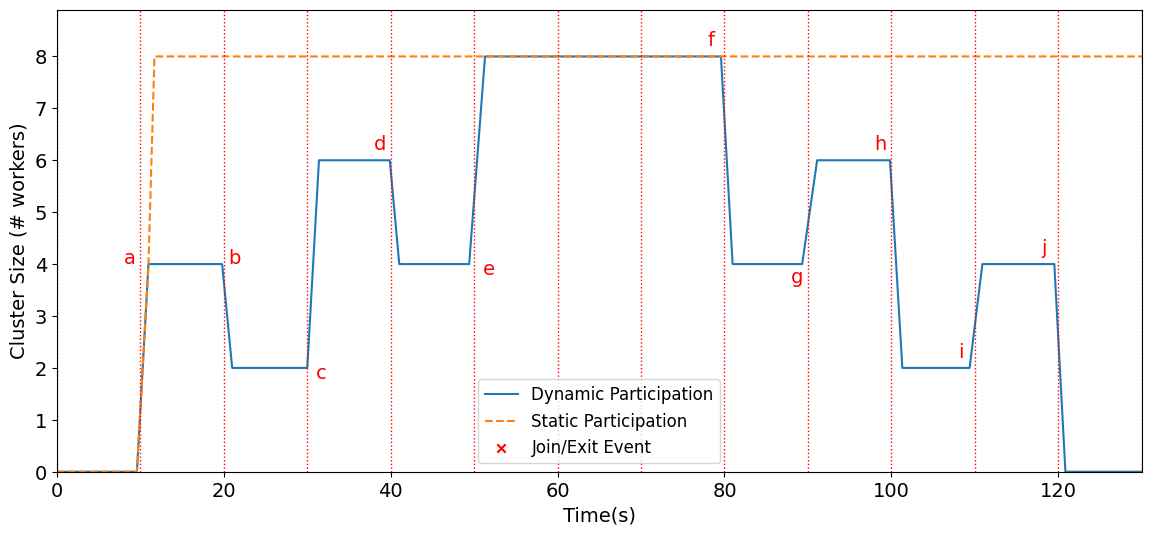

In [79]:
fig, ax = plt.subplots(figsize=(14,6))

ax.plot([x["time"] for x in elasticity_data], [x["dynamic_workers"] for x in elasticity_data], label="Dynamic Participation")
ax.plot([x["time"] for x in elasticity_data], [x["static_workers"] for x in elasticity_data], label="Static Participation", linestyle='dashed')
ax.scatter([10], [100], marker="x", c="r", label="Join/Exit Event")
plt.legend(loc="lower center", fontsize=12)

ax.xaxis.set_major_formatter(FormatStrFormatter('%.0f/'))
ax.set_xticklabels([x*20 for x in range(0, 15)])
ax.set_ylim(0, 8.9)
ax.set_xlim(0, 130)
ax.set_xlabel("Time(s)", fontsize=14)
ax.set_ylabel("Cluster Size (# workers)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)

for i in range(0, 15):
    plt.axvline(x=i*10, color='red', linestyle='dotted', label='Join', linewidth=1)
ax.annotate("a", (8, 4), c="r", fontsize=14)
ax.annotate("b", (20.5, 4), c="r", fontsize=14)
ax.annotate("c", (31, 1.8), c="r", fontsize=14)
ax.annotate("d", (38, 6.2), c="r", fontsize=14)
ax.annotate("e", (51, 3.8), c="r", fontsize=14)
ax.annotate("f", (78, 8.2), c="r", fontsize=14)
ax.annotate("g", (88, 3.65), c="r", fontsize=14)
ax.annotate("h", (98, 6.2), c="r", fontsize=14)
ax.annotate("i", (108, 2.2), c="r", fontsize=14)
ax.annotate("j", (118, 4.2), c="r", fontsize=14)

# RESOURCE EFFICIENCY

In [80]:
abs_time_data = None
with open("final_absolute_time_data", 'r') as file:
    abs_time_data = json.load(file)

In [81]:
abs_time_data

{'3': {'2_workers_wasted_time': 6.686927056312561,
  '4_workers_wasted_time': 8.849910712242126,
  '6_workers_wasted_time': 9.350935912132263,
  '8_workers_wasted_time': 10.2},
 '5': {'2_workers_wasted_time': 11.7333327293396,
  '4_workers_wasted_time': 11.966361737251281,
  '6_workers_wasted_time': 12.552690267562866,
  '8_workers_wasted_time': 13.3},
 '8': {'2_workers_wasted_time': 19.332403779029846,
  '4_workers_wasted_time': 17.289075446128845,
  '6_workers_wasted_time': 18.960738754272462,
  '8_workers_wasted_time': 19.1},
 '13': {'2_workers_wasted_time': 22.08501977920532,
  '4_workers_wasted_time': 29.966911363601685,
  '6_workers_wasted_time': 28.469619727134706,
  '8_workers_wasted_time': 29.6},
 '20': {'2_workers_wasted_time': 37.167309975624086,
  '4_workers_wasted_time': 38.61002254486084,
  '6_workers_wasted_time': 48.43750712871552,
  '8_workers_wasted_time': 44.2}}

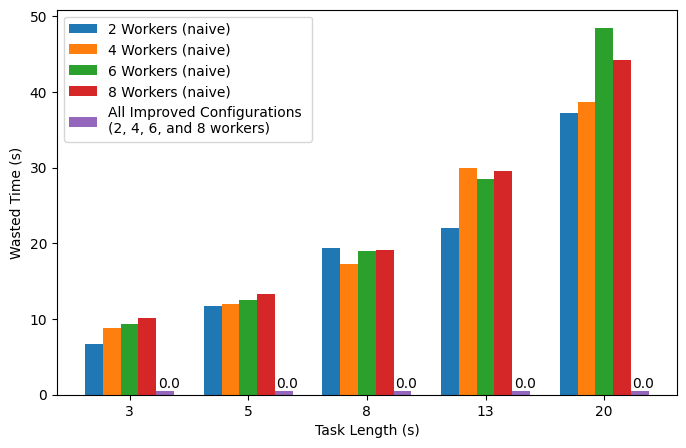

In [82]:
import matplotlib as mpl

groups = ['3', '5', '8', '13', '20']
pairs2 = [x["2_workers_wasted_time"] for x in abs_time_data.values()]
pairs4 = [x["4_workers_wasted_time"] for x in abs_time_data.values()]
pairs6 = [x["6_workers_wasted_time"] for x in abs_time_data.values()]
pairs8 = [x["8_workers_wasted_time"] for x in abs_time_data.values()]
statics = [0.5]*5


cs = mpl.color_sequences['tab10'][0:]
bar_width = 0.15
x = np.arange(len(groups))

fig, ax = plt.subplots(figsize=(8, 5))

ax.bar(x - 2 * bar_width, pairs2, width=bar_width, label='2 Workers (naive)', color=cs[0])
ax.bar(x - bar_width, pairs4, width=bar_width, label='4 Workers (naive)', color=cs[1])
ax.bar(x, pairs6, width=bar_width, label='6 Workers (naive)', color=cs[2])
ax.bar(x + bar_width, pairs8, width=bar_width, label='8 Workers (naive)', color=cs[3])
bar_10 = ax.bar(x + 2 * bar_width, statics, width=bar_width, label='All Improved Configurations \n(2, 4, 6, and 8 workers)', color=cs[4])  # Added fifth bar

for rect in bar_10:
    ax.text(rect.get_x() + rect.get_width() / 2 + 0.03, rect.get_height(), '0.0', 
            ha='center', va='bottom', fontsize=10, color='black')

ax.set_xlabel('Task Length (s)')
ax.set_ylabel('Wasted Time (s)')
ax.set_xticks(x)
ax.set_xticklabels(groups)
ax.legend()

In [83]:
agg_eff_data = None
with open("final_aggregate_efficiency_data", 'r') as file:
    agg_eff_data = json.load(file)

In [84]:
agg_eff_data

{'duration_3': [72.25314369017761,
  81.73396809473721,
  87.25048098938593,
  92.5325719201098],
 'duration_5': [70.72131339781167,
  85.1288217111492,
  89.64607587093121,
  94.5083750584267],
 'duration_8': [69.8276722487402,
  86.55397640593307,
  90.20358130643555,
  92.9850385938586],
 'duration_13': [78.78562598937724,
  85.63358193082642,
  90.91401469856669,
  95.2748394758939],
 'duration_20': [76.78807198092464,
  87.95555541440976,
  89.93631084527797,
  94.9282859817592]}

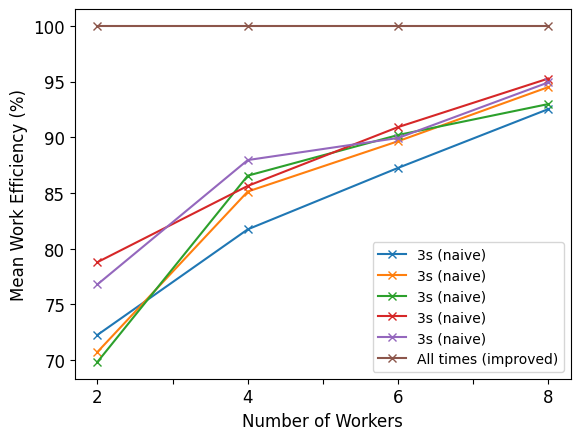

In [85]:
fig, ax = plt.subplots()

aggs = list(agg_eff_data.values())

for i in range(5):
    plt.plot([2, 4, 6, 8], aggs[i], "-x", label="3s (naive)")

plt.plot([2, 4, 6, 8], [100]*4, "-x", label="All times (improved)")
plt.legend()
plt.xlabel("Number of Workers", fontsize=12)
plt.ylabel("Mean Work Efficiency (%)", fontsize=12)
plt.xticks(fontsize=12)
plt.yticks(fontsize=12)
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)

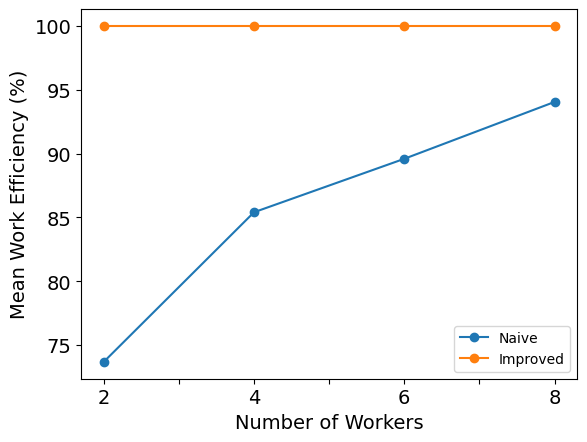

In [86]:
average_y = np.mean(aggs, axis=0)
fig, ax = plt.subplots()

plt.plot([2, 4, 6, 8], average_y, '-o', label="Naive")
plt.plot([2, 4, 6, 8], [100]*4, '-o', label="Improved")
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)

plt.xlabel("Number of Workers", fontsize=14)
plt.ylabel("Mean Work Efficiency (%)", fontsize=14)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.legend()

In [87]:
n_exit_data = None
with open("final_multiple_exit_data", 'r') as file:
    n_exit_data = json.load(file)

In [88]:
n_exit_data

{'4_workers': [65.7699437105413, 44.0558878357534],
 '6_workers': [82.45082336083874,
  74.5140574469266,
  53.53487290428875,
  30.744722527108415],
 '8_workers': [87.09867589613292,
  77.00411329671877,
  67.0570934513987,
  50.314050807369,
  27.942901091191885,
  15.007777024646806]}

In [89]:
n4 = n_exit_data["4_workers"]
n6 = n_exit_data["6_workers"]
n8 = n_exit_data["8_workers"]

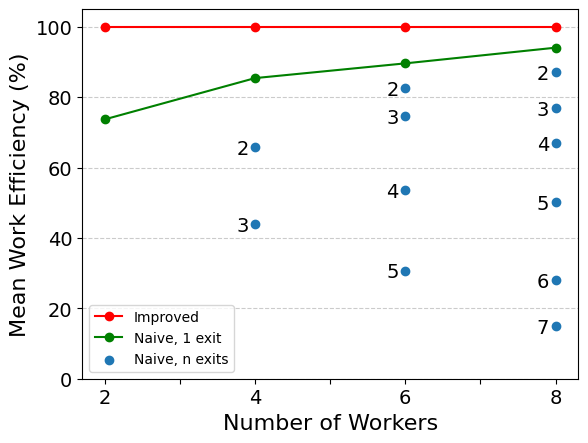

In [90]:
fig, ax = plt.subplots()
statics = [100, 100, 100, 100]

plt.plot([2, 4, 6, 8], statics, "-o", c="r", label="Improved")
plt.plot([2, 4, 6, 8], average_y, "-o", c="g", label="Naive, 1 exit")
plt.scatter([4]*len(n4), n4, marker="o", c="C0", label="Naive, n exits")
ax.annotate("2", (4-0.25, n4[0]-2), fontsize=14)
ax.annotate("3", (4-0.25, n4[1]-2), fontsize=14)
plt.scatter([6]*len(n6), n6, c="C0")
ax.annotate("2", (6-0.25, n6[0]-2), fontsize=14)
ax.annotate("3", (6-0.25, n6[1]-2), fontsize=14)
ax.annotate("4", (6-0.25, n6[2]-2), fontsize=14)
ax.annotate("5", (6-0.25, n6[3]-2), fontsize=14)
plt.scatter([8]*len(n8), n8, c="C0")
ax.annotate("2", (8-0.25, n8[0]-2), fontsize=14)
ax.annotate("3", (8-0.25, n8[1]-2), fontsize=14)
ax.annotate("4", (8-0.25, n8[2]-2), fontsize=14)
ax.annotate("5", (8-0.25, n8[3]-2), fontsize=14)
ax.annotate("6", (8-0.25, n8[4]-2), fontsize=14)
ax.annotate("7", (8-0.25, n8[5]-2), fontsize=14)


plt.ylim(0, 105)
plt.xlabel("Number of Workers", fontsize=16)
plt.ylabel("Mean Work Efficiency (%)", fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
for label in ax.xaxis.get_ticklabels()[::2]:
    label.set_visible(False)
plt.legend()

plt.grid(True, linestyle='--', axis="y", alpha=0.65)